# **EJERCICIO 4 PANDAS**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos
df = pd.read_csv('user_behavior_dataset.csv')

In [ ]:
# 1.1.	Muestra las primeras filas del dataset para familiarizarte con los datos.
print("1. Primeras filas:")
print(df.head())

#2.	Renombra las columnas del dataset para que tengan nombres más manejables en Python.
df.columns = ['user_id', 'device_model', 'os', 'app_usage_min', 
            'screen_time_h', 'battery_drain_mah', 'num_apps', 
            'data_usage_mb', 'age', 'gender', 'behavior_class']
print("\n2. Columnas renombradas:")
print(df.columns.tolist())

# 3. Verifica si hay valores nulos en el dataset y cuántos hay por columna.
print("\n3. Valores nulos por columna:")
print(df.isnull().sum())

# 4.	Identifica al usuario con el mayor tiempo diario de uso de aplicaciones.
print("\n4. Usuario con mayor uso apps:")
max_user = df.loc[df['app_usage_min'].idxmax()]
print(f"User ID: {max_user['user_id']}, Tiempo: {max_user['app_usage_min']} min")

# 5.	Calcula la edad promedio de los usuarios en cada clase de comportamiento.
print("\n5. Edad promedio por clase:")
print(df.groupby('behavior_class')['age'].mean())

# 6. 6.	Agrupa los datos por sistema operativo y clase de comportamiento del usuario, 
# y calcula el promedio de tiempo diario de uso de aplicaciones para cada grupo
print("\n6. Promedio app usage por OS y clase:")
print(df.groupby(['os', 'behavior_class'])['app_usage_min'].mean())

# 7. Total users por genero
print("\n7. Total usuarios por género:")
print(df['gender'].value_counts())


1. Primeras filas:
   user_id    device_model       os  app_usage_min  screen_time_h  \
0        1  Google Pixel 5  Android            393            6.4   
1        2       OnePlus 9  Android            268            4.7   
2        3    Xiaomi Mi 11  Android            154            4.0   
3        4  Google Pixel 5  Android            239            4.8   
4        5       iPhone 12      iOS            187            4.3   

   battery_drain_mah  num_apps  data_usage_mb  age  gender  behavior_class  
0               1872        67           1122   40    Male               4  
1               1331        42            944   47  Female               3  
2                761        32            322   42    Male               2  
3               1676        56            871   20    Male               3  
4               1367        58            988   31  Female               3  

2. Columnas renombradas:
['user_id', 'device_model', 'os', 'app_usage_min', 'screen_time_h', 'battery_d

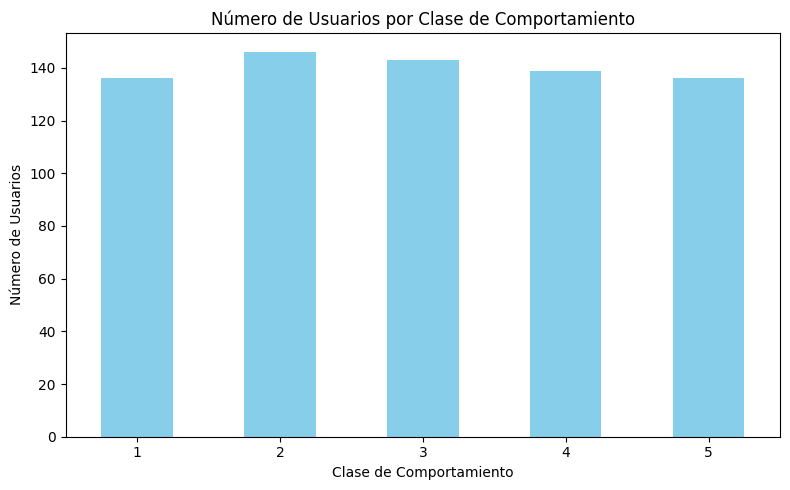

In [4]:
# 8. Gráfico usuarios por clase comportamiento
plt.figure(figsize=(8, 5))
df['behavior_class'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Número de Usuarios por Clase de Comportamiento')
plt.xlabel('Clase de Comportamiento')
plt.ylabel('Número de Usuarios')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('usuarios_por_clase.png')
plt.show()


In [ ]:
# 9. Promedio uso datos por género
print("\n9. Promedio datos móviles por género:")
print(df.groupby('gender')['data_usage_mb'].mean())

# 10.	Determina el consumo total de batería por modelo de dispositivo.
print("\n10. Consumo total batería por modelo:")
print(df.groupby('device_model')['battery_drain_mah'].sum().sort_values(ascending=False))

# 11.	Filtra y muestra a los usuarios que tienen más de 200 minutos diarios de uso de aplicaciones.
print("\n11. Usuarios con >200 min uso apps:")
usuarios_200 = df[df['app_usage_min'] > 200]
print(usuarios_200[['user_id', 'app_usage_min', 'device_model']])



9. Promedio datos móviles por género:
gender
Female    914.321429
Male      943.978022
Name: data_usage_mb, dtype: float64

10. Consumo total batería por modelo:
device_model
iPhone 12             232069
Xiaomi Mi 11          223216
Google Pixel 5        209546
OnePlus 9             202672
Samsung Galaxy S21    200108
Name: battery_drain_mah, dtype: int64

11. Usuarios con >200 min uso apps:
     user_id  app_usage_min        device_model
0          1            393      Google Pixel 5
1          2            268           OnePlus 9
3          4            239      Google Pixel 5
6          7            350  Samsung Galaxy S21
7          8            543           OnePlus 9
..       ...            ...                 ...
692      693            378        Xiaomi Mi 11
693      694            505        Xiaomi Mi 11
694      695            564  Samsung Galaxy S21
696      697            316        Xiaomi Mi 11
699      700            212           OnePlus 9

[392 rows x 3 columns]


In [ ]:
# 12.	Crea una nueva columna que calcule el tiempo total diario activo 
# combinando el tiempo de pantalla encendida y el tiempo de uso de aplicaciones.
df['screen_time_min'] = df['screen_time_h'] * 60
df['total_active_min'] = df['screen_time_min'] + df['app_usage_min']
print("\n12. Nueva columna 'total_active_min':")
print(df[['user_id', 'app_usage_min', 'screen_time_h', 'total_active_min']].head())



12. Nueva columna 'total_active_min':
   user_id  app_usage_min  screen_time_h  total_active_min
0        1            393            6.4             777.0
1        2            268            4.7             550.0
2        3            154            4.0             394.0
3        4            239            4.8             527.0
4        5            187            4.3             445.0


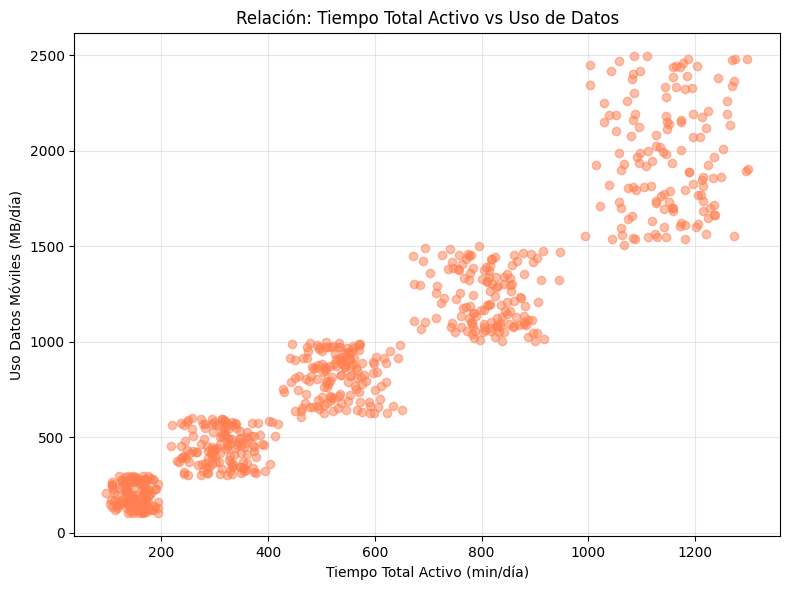

In [ ]:
# 13.	Representa en un gráfico de dispersión la relación 
# entre el tiempo total diario activo y el uso diario de datos móviles
plt.figure(figsize=(8, 6))
plt.scatter(df['total_active_min'], df['data_usage_mb'], alpha=0.5, c='coral')
plt.title('Relación: Tiempo Total Activo vs Uso de Datos')
plt.xlabel('Tiempo Total Activo (min/día)')
plt.ylabel('Uso Datos Móviles (MB/día)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dispersion_tiempo_datos.png')
plt.show()



14. Promedio apps por clase:
behavior_class
1    14.558824
2    30.753425
3    50.000000
4    69.920863
5    89.250000
Name: num_apps, dtype: float64


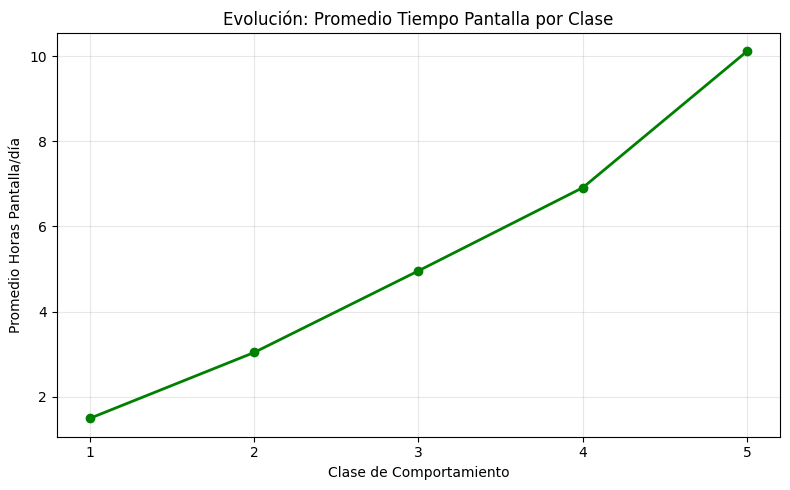

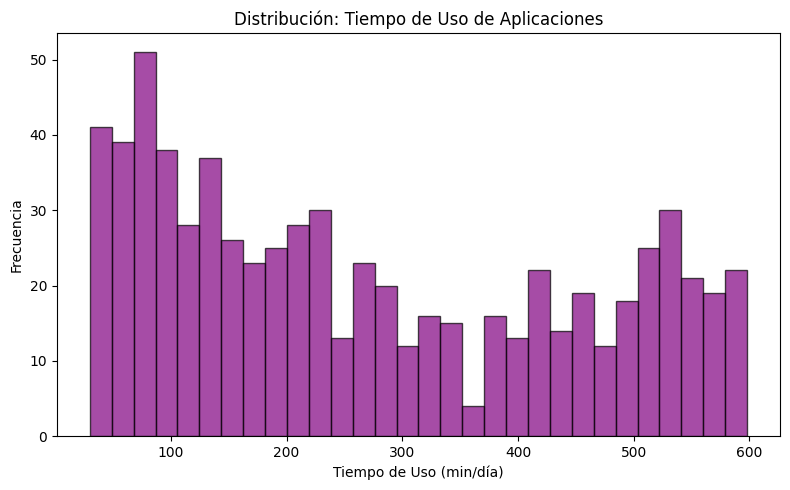

In [ ]:
# 14.	Calcula el promedio de aplicaciones instaladas para cada clase de comportamiento.
print("\n14. Promedio apps por clase:")
print(df.groupby('behavior_class')['num_apps'].mean())


# 15. Representa en un gráfico de líneas la evolución del promedio de tiempo de pantalla encendida
# por clase de comportamiento del usuario. 
# Crear un histograma para representar la distribución del tiempo de uso de aplicaciones


# 15a. Gráfico líneas: pantalla encendida por clase
plt.figure(figsize=(8, 5))
promedio_pantalla = df.groupby('behavior_class')['screen_time_h'].mean()
plt.plot(promedio_pantalla.index, promedio_pantalla.values, marker='o', color='green', linewidth=2)
plt.title('Evolución: Promedio Tiempo Pantalla por Clase')
plt.xlabel('Clase de Comportamiento')
plt.ylabel('Promedio Horas Pantalla/día')
plt.xticks(promedio_pantalla.index)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('linea_pantalla_clase.png')
plt.show()

# 15b. Histograma: distribución tiempo uso apps
plt.figure(figsize=(8, 5))
plt.hist(df['app_usage_min'], bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.title('Distribución: Tiempo de Uso de Aplicaciones')
plt.xlabel('Tiempo de Uso (min/día)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('histograma_uso_apps.png')
plt.show()
